In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
# %pip install matplotlib pandas seaborn numpy 

In [4]:
df=pd.read_csv(r"C:\Users\DELL\Downloads\DDO-Semiconductor-main\DDO-Semiconductor-main\data\ChipPerformance.csv")
df

,Unnamed: 0,Product,Type,Release Date,Process Size (nm),TDP (W),Die Size (mm^2),Transistors (million),Freq (MHz),Foundry,Vendor,FP16 GFLOPS,FP32 GFLOPS,FP64 GFLOPS
0,0,AMD Athlon 64 3500+,CPU,2007-02-20,65.0,45.0,77.0,122.0,2200.0,Unknown,AMD,NaN,NaN,NaN
1,1,AMD Athlon 200GE,CPU,2018-09-06,14.0,35.0,192.0,4800.0,3200.0,Unknown,AMD,NaN,NaN,NaN
2,2,Intel Core i5-1145G7,CPU,2020-09-02,10.0,28.0,NaN,NaN,2600.0,Intel,Intel,NaN,NaN,NaN
3,3,Intel Xeon E5-2603 v2,CPU,2013-09-01,22.0,80.0,160.0,1400.0,1800.0,Intel,Intel,NaN,NaN,NaN
4,4,AMD Phenom II X4 980 BE,CPU,2011-05-03,45.0,125.0,258.0,758.0,3700.0,Unknown,AMD,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4849,4849,NVIDIA Quadro 3000M,GPU,2011-02-22,40.0,75.0,332.0,1950.0,450.0,TSMC,NVIDIA,NaN,432.0,36.0
4850,4850,Intel GMA 950,GPU,2005-06-01,90.0,7.0,NaN,NaN,250.0,Intel,Intel,NaN,NaN,NaN
4851,4851,NVIDIA GeForce GT 320M,GPU,2010-03-03,40.0,23.0,100.0,486.0,500.0,TSMC,NVIDIA,NaN,52.8,NaN
4852,4852,NVIDIA GeForce FX 5200,GPU,2003-03-06,150.0,NaN,65.0,29.0,250.0,TSMC,NVIDIA,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4854 entries, 0 to 4853
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             4854 non-null   int64  
 1   Product                4854 non-null   str    
 2   Type                   4854 non-null   str    
 3   Release Date           4854 non-null   str    
 4   Process Size (nm)      4845 non-null   float64
 5   TDP (W)                4228 non-null   float64
 6   Die Size (mm^2)        4139 non-null   float64
 7   Transistors (million)  4143 non-null   float64
 8   Freq (MHz)             4854 non-null   float64
 9   Foundry                4854 non-null   str    
 10  Vendor                 4854 non-null   str    
 11  FP16 GFLOPS            536 non-null    float64
 12  FP32 GFLOPS            1948 non-null   float64
 13  FP64 GFLOPS            1306 non-null   float64
dtypes: float64(8), int64(1), str(5)
memory usage: 531.0 KB


In [6]:
df.describe()

,Unnamed: 0,Process Size (nm),TDP (W),Die Size (mm^2),Transistors (million),Freq (MHz),FP16 GFLOPS,FP32 GFLOPS,FP64 GFLOPS
count,4854.000000,4845.000000,4228.000000,4139.000000,4143.000000,4854.000000,536.000000,1948.000000,1306.000000
mean,2426.500000,55.109598,81.359981,188.440445,1929.922279,1484.406057,8397.459851,2134.756653,363.670511
std,1401.373433,44.998676,76.807808,126.189383,4044.891098,1066.701523,13799.551131,3898.431487,1145.931856
min,0.000000,0.000000,1.000000,1.000000,8.000000,100.000000,10.020000,12.800000,3.600000
25%,1213.250000,22.000000,33.000000,104.000000,154.000000,590.000000,768.800000,257.300000,38.295000
50%,2426.500000,40.000000,65.000000,148.000000,624.000000,1073.500000,2965.500000,696.000000,89.280000
75%,3639.750000,90.000000,100.000000,239.000000,1550.000000,2400.000000,10600.000000,2116.750000,220.000000
max,4853.000000,250.000000,900.000000,826.000000,54200.000000,4700.000000,184600.000000,40000.000000,11540.000000


ANALYSIS OF DATA --> TAKING THREE NUMERICAL COLUMNS ( PROCESSOR SIZE, TRANSISTOR, AND TDP )

In [7]:
# analysis of data 
sns.set(style="whitegrid")

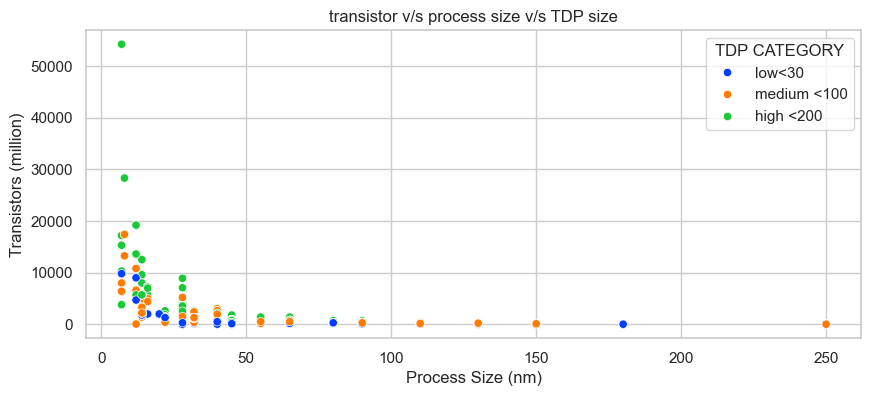

In [8]:
plt.figure(figsize=(10,4)) 

# I HAVE TO MAKE BINS FOR IT, BCOZ THEY ARE A LOT,  IT IS LIKE MAKING A NEW CLOUMN FROM DF, --> 
df["TDP CATEGORY"]=pd.cut(df["TDP (W)"],bins=[0,30,100,200],labels=["low<30","medium <100","high <200"]) 

sns.scatterplot(data=df,x="Process Size (nm)",y="Transistors (million)",hue="TDP CATEGORY",palette="bright")
plt.title("transistor v/s process size v/s TDP size")
plt.show()

It shows that as transistor size increases the process size decreases and that also lead to high TDP               
This is also known as morre's law    
 "-----------------------------------------------------------------------------------------------------"

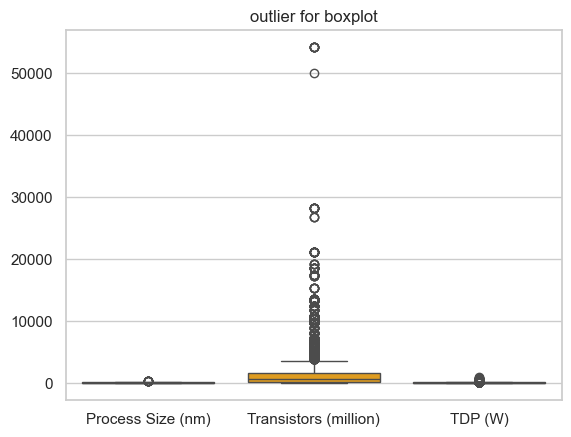

In [9]:
# for outlieres use box plot 

num_col=["Process Size (nm)","Transistors (million)","TDP (W)"]
fig,axes=plt.subplots()
sns.boxplot(df[num_col],color="orange")
plt.tight_layout
plt.title("outlier for boxplot")
plt.show()

Making a time series graph for transisitor and process count by years    
 "-------------------------------------------------------------------"

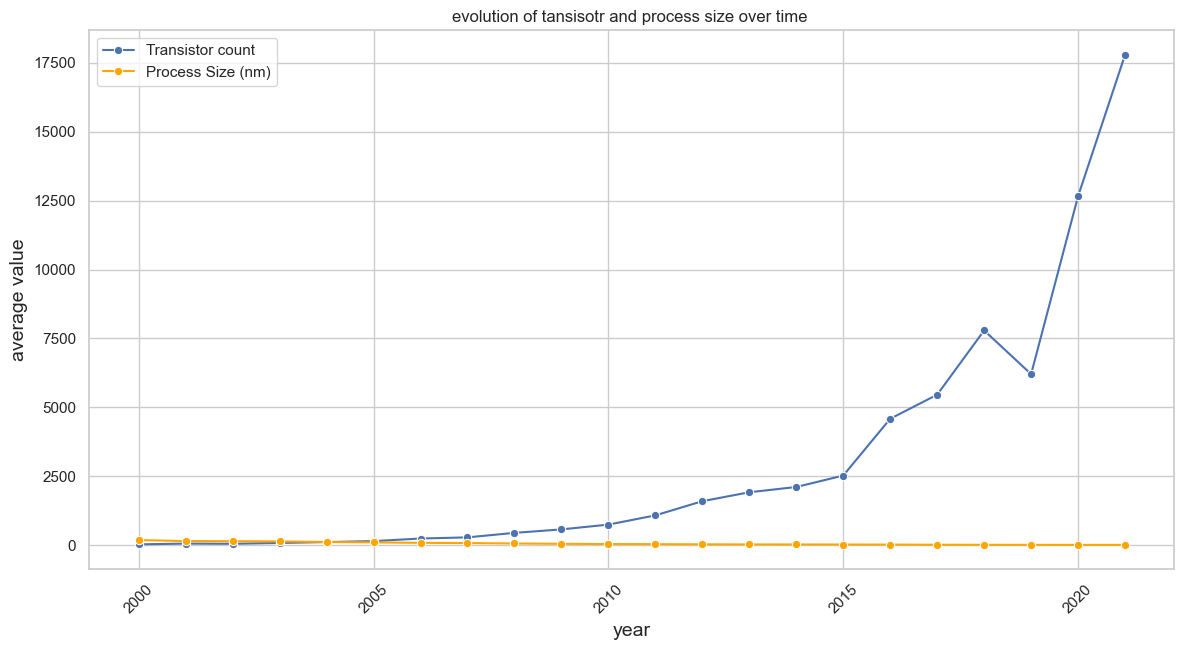

In [10]:
# convert it to proper date and time object  , coerce -> if data is bad convert it to NAT
df["Release Date"]=pd.to_datetime(df["Release Date"],errors="coerce") 

df["year"]=df["Release Date"].dt.year # only extracting the year ,group data by year , makes new column 

# grouping it by year, then telling to aggregate by means in every year bucket (transistor and process size) 
# group by concvert coloumn to index , reset index reset to deafault year here . 

yearly_data=df.groupby("year").agg({"Transistors (million)":"mean","Process Size (nm)":"mean"}).reset_index()

plt.figure(figsize=(14,7))
sns.lineplot(x="year",y="Transistors (million)",data=yearly_data,label="Transistor count",marker="o")  
sns.lineplot(x="year",y="Process Size (nm)",data=yearly_data,label="Process Size (nm)",marker="o",color="orange")  

plt.title("evolution of tansisotr and process size over time ")
plt.xlabel("year",fontsize=14)
plt.ylabel("average value",fontsize=14)
plt.xticks(rotation=45)
plt.legend()
plt.show()

YOU CAN SEE AS TRANSISTOR SIZE IS INCREASING    
PROCESS SIZE IS DECEASING   
 "------------------------------------------------------"

DATA PREPEATION STAGE

In [11]:
# we are going to fill these cells that have null value to median 

df["Process Size (nm)"]=df["Process Size (nm)"].fillna(df["Process Size (nm)"].median())
df["TDP (W)"]=df["TDP (W)"].fillna(df["TDP (W)"].median())
df["Transistors (million)"]=df["Transistors (million)"].fillna(df["Transistors (million)"].median())
df["Die Size (mm^2)"]=df["Die Size (mm^2)"].fillna(df["Die Size (mm^2)"].median())

# filling null values to zero 

df["FP16 GFLOPS"]=df["FP16 GFLOPS"].fillna(0)
df["FP32 GFLOPS"]=df["FP32 GFLOPS"].fillna(0)
df["FP64 GFLOPS"]=df["FP64 GFLOPS"].fillna(0)


In [12]:
# dropping values that have null values in release date and year as it can affect the ananlysis 
df=df.dropna(subset=["Release Date","year"])

# now making new columns for better understanding of data --> 
df["'Transistor Density (million per mm^2)'"]=df["Transistors (million)"]/df["Die Size (mm^2)"]

df["FP16 GFLOPS per W"]=df["FP16 GFLOPS"]/df["TDP (W)"]
df["FP32 GFLOPS per W"]=df["FP32 GFLOPS"]/df["TDP (W)"]
df["FP64 GFLOPS per W"]=df["FP64 GFLOPS"]/df["TDP (W)"]

missing_dat_aft=df.isnull().sum().sort_values(ascending=False)   # finding null values in it if left 
print("missing data after refining",missing_dat_aft)

import os 
# saving the new file after refining it  
output_folder='../Outputs_ChipPerformance'
output_file='ChipPerformance_Prep1.csv'
# combining in full path

output_path = os.path.join(output_folder, output_file)

if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    print(f"created directory : {output_folder}")

# save the data frame to specific path 
df.to_csv(output_path,index=False) # omitting the index 
print(f"file saved to : {output_path}")


missing data after refining TDP CATEGORY                               944
Unnamed: 0                                   0
Type                                         0
Product                                      0
Release Date                                 0
Process Size (nm)                            0
Die Size (mm^2)                              0
TDP (W)                                      0
Freq (MHz)                                   0
Foundry                                      0
Vendor                                       0
Transistors (million)                        0
FP16 GFLOPS                                  0
FP32 GFLOPS                                  0
FP64 GFLOPS                                  0
year                                         0
'Transistor Density (million per mm^2)'      0
FP16 GFLOPS per W                            0
FP32 GFLOPS per W                            0
FP64 GFLOPS per W                            0
dtype: int64
file saved to : ../

"--------------------------------"  
DATA TRANSFORMATION AND SCALING     
"--------------------------------"  

In [13]:
#%pip install scikit-learn

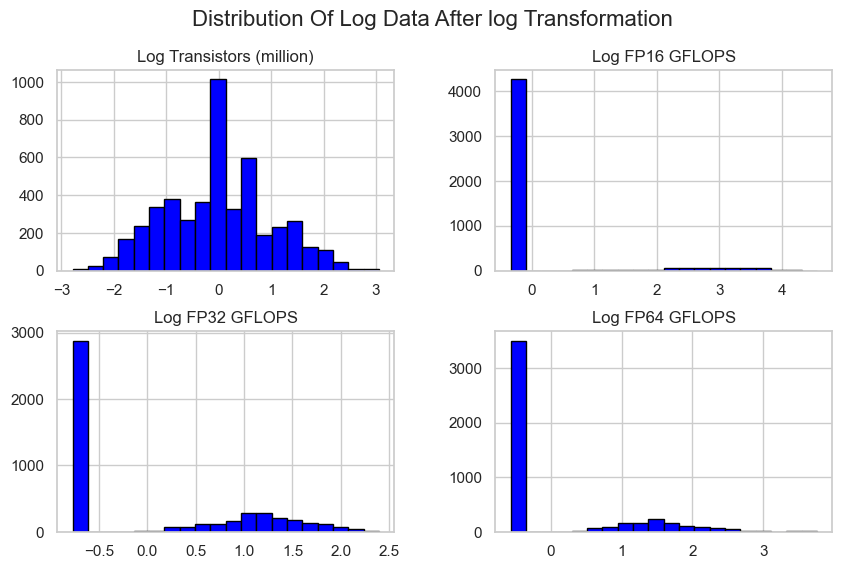

transformed data save to ../Outputs_ChipPerformance/ChipPerformance_Prep2.csv


In [14]:
from sklearn.preprocessing import StandardScaler

# LOG TRANSFORMATION 
# load previous dataset so that all previous cleaning steps are taken in consideration 
input_path=r"../Outputs_ChipPerformance\ChipPerformance_Prep1.csv"
chip_data=pd.read_csv(input_path)

#applying log to highly skewed data to reduce skewness making data  normally distributed and then scaling the data
# which is important for machine learning model 

chip_data["Log Transistors (million)"]=np.log1p(chip_data["Transistors (million)"])
chip_data["Log FP16 GFLOPS"]=np.log1p(chip_data["FP16 GFLOPS"])   # TO get correct value, np.log1p is log(1+x), 
chip_data["Log FP32 GFLOPS"]=np.log1p(chip_data["FP32 GFLOPS"])   # we dont use log(1+x) literally as it can lead to rounding off 
chip_data["Log FP64 GFLOPS"]=np.log1p(chip_data["FP64 GFLOPS"])   # that can ignore the vlaue of x in approx.

# SCALING
# it will help to all factors so that they can contribute equally to ananlysis

numerical_col=['TDP (W)', 'Die Size (mm^2)', 'Freq (MHz)', 
                  'Log Transistors (million)', 'Log FP16 GFLOPS', 
                  'Log FP32 GFLOPS', 'Log FP64 GFLOPS']

scaler=StandardScaler()  #container that will store the parameters of data( mean, standard deviation)

chip_data[numerical_col]=scaler.fit_transform(chip_data[numerical_col]) # calculated the mean and sd and then tranform each value using z formula 


# visulize the data again as it is important to see how our data has the intended effect 

tranformed_column=["Log Transistors (million)","Log FP16 GFLOPS","Log FP32 GFLOPS","Log FP64 GFLOPS"]
chip_data[tranformed_column].hist(figsize=(10,6),bins=20,color="blue",edgecolor="black")
plt.suptitle("Distribution Of Log Data After log Transformation",fontsize=16)
plt.show()

# saving the transformation 
output_folder=r"../Outputs_ChipPerformance"
output_file="ChipPerformance_Prep2.csv"
output_path=f"{output_folder}/{output_file}"

# save dataframe to a path 
# index=False instructs pandas to omit this index column ( index =0,1,2..)
# which is usually preferred because the index is often redundant and can cause issues if you reload the file later.
chip_data.to_csv(output_path,index=False)

print(f"transformed data save to {output_path}") 

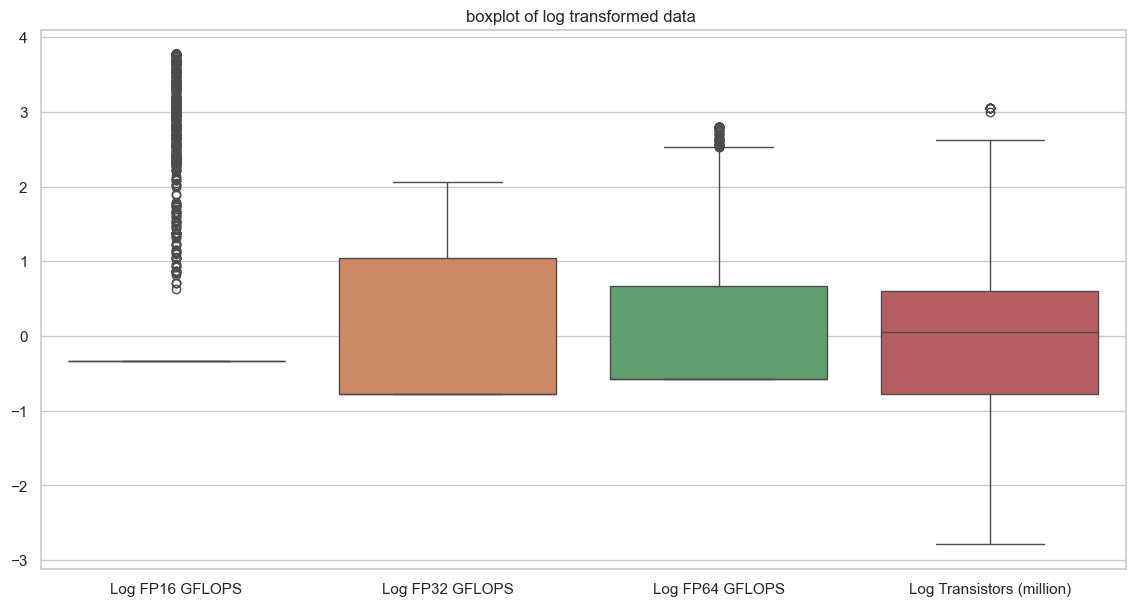

Dataset with capped outlier saved to path ../Outputs_ChipPerformance/ChipPerformance_Prep3.csv


In [15]:
#loading prev data so that we get transformed values
input_path=r"../Outputs_ChipPerformance/ChipPerformance_Prep2.csv"

chip_data=pd.read_csv(input_path)

def cap_oulier(series):
    lower_cap=series.quantile(0.01)
    upper_cap=series.quantile(0.99)
    return series.clip(lower=lower_cap,upper=upper_cap)

#'Log FP16 GFLOPS', 'Log FP32 GFLOPS', and 'Log FP64 GFLOPS' has significant ouliers, cap makes dataset robust

chip_data["Log FP16 GFLOPS"]=cap_oulier(chip_data["Log FP16 GFLOPS"])
chip_data["Log FP32 GFLOPS"]=cap_oulier(chip_data["Log FP32 GFLOPS"])
chip_data["Log FP64 GFLOPS"]=cap_oulier(chip_data["Log FP64 GFLOPS"])

#Recheck the boxplots after capping to ensure outliers are appropriately handled

plt.figure(figsize=(14,7))
sns.boxplot(data=chip_data[['Log FP16 GFLOPS', 'Log FP32 GFLOPS','Log FP64 GFLOPS',"Log Transistors (million)"]])
plt.title("boxplot of log transformed data ")
plt.show()

#It's normal and acceptable to have some outliers remain even after capping, as long as their influence on the model is minimized

# saving dataset

output_folder="../Outputs_ChipPerformance"
output_file="ChipPerformance_Prep3.csv"
output_path=f"{output_folder}/{output_file}"

chip_data.to_csv(output_path, index=False)
print(f"Dataset with capped outlier saved to path {output_path}")
